In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ask_llm(prompt, fallback="(no API key set — showing a pre-written sample answer)", max_tokens=700):
    """Call Claude if ANTHROPIC_API_KEY is set; else return the fallback so the notebook always runs."""
    try:
        import anthropic
        client = anthropic.Anthropic()
        msg = client.messages.create(model="claude-sonnet-4-5-20250929", max_tokens=max_tokens,
                                      messages=[{"role": "user", "content": prompt}])
        return msg.content[0].text
    except Exception as e:
        print(f"[Using fallback — reason: {type(e).__name__}]")
        return fallback

print("Ready.")


Ready.


---
## Part 1 — Following are 2 ways to value a company:


| | **DCF (intrinsic)** | **Multiples (relative)** |
|---|---|---|
| The question | What cash will this business produce, and what is that cash worth *today*? | What are similar companies selling for, per rupee of profit/EBITDA? |
| Analogy | Valuing a mango tree by the mangoes it will grow | Valuing your flat by what the neighbour's identical flat sold for |
| Strength | Grounded in the actual business | Fast, market-based, fewer assumptions |
| Weakness | Very sensitive to assumptions (especially far-future ones) | Only as good as the "comparables"; inherits market mood |

Good analysts use **both** and treat the answer as a **range**, not a single number. We'll see them disagree — and that disagreement is informative.



- **Earnings or Revenue** — total sales.
- **EBITDA** — earnings before interest, tax, depreciation & amortisation (a rough proxy for operating cash generation). **EBIT** — EBITDA minus depreciation (operating profit). **PAT** — profit after tax (the "bottom line").
- **OCF** = EBIT + D&A - Taxes
- **FCF** (Free cash flow (FCF) comes from a company's core business earnings and daily operations)
   
*    **FCF** = OCF - Net Capital Spending - Net working capital



- **Net debt** — total borrowings minus cash. **Shares outstanding** — how the equity is sliced (here, 40 crore shares).


**Assumptions**
For illustrative purspose, we choose Earnings and related Income statement vallues from "financials_summary"



In [5]:
fin = pd.read_csv("/financials_summary.csv")
print("Bharat Logitech — historical summary (Rs crore):")
print(fin.to_string(index=False))

Bharat Logitech — historical summary (Rs crore):
                       item  FY23  FY24  FY25
                    Revenue  7560  8623 10000
                     EBITDA   945  1069  1113
Depreciation & Amortisation   257   293   345
                       EBIT   688   776   768
           Interest expense   142   151   168
          Profit before tax   546   625   600
                        Tax   137   156   150
     Profit after tax (PAT)   409   469   612
                      Capex   416   474   542
                   Net debt  1180  1290  1420
 Shares outstanding (crore)    40    40    40


## The discount rate (WACC)

Using CAPM equation:
WACC is a sum of: :

- Cost of equity — what shareholders demand. We estimate it with CAPM: ( R_e = R_f + β(E(R_m) - R_f)
i.e. cost of equity = risk-free rate + beta x equity risk premium (beta measures how much the stock swings vs the market; equity risk premium is the extra return stocks demand over safe government bonds.)
- Cost of debt — the interest rate on borrowings, after tax (interest is tax-deductible, so debt is cheaper than it looks).
Then we blend them by how much equity vs debt funds the business.

In [12]:
assumptions = pd.read_csv("/dcf_assumptions.csv").set_index("assumption")["value"]

rf   = assumptions["risk_free_rate"]
erp  = assumptions["equity_risk_premium"]
beta = assumptions["beta"]
tax  = assumptions["tax_rate"]

cost_equity = rf + beta * erp                       # CAPM
cost_debt_post = a["pre_tax_cost_of_debt"] * (1 - tax)  # after-tax cost of debt
we, wd = a["weight_equity"], a["weight_debt"]
wacc = we * cost_equity + wd * cost_debt_post

print(f"Cost of equity (CAPM)   = {rf:.3f} + {beta} x {erp:.3f} = {cost_equity:.2%}")
print(f"After-tax cost of debt  = {a['pre_tax_cost_of_debt']:.2%} x (1 - {tax:.0%}) = {cost_debt_post:.2%}")
print(f"WACC = {we:.0%} x {cost_equity:.2%} + {wd:.0%} x {cost_debt_post:.2%} = {wacc:.2%}")


Cost of equity (CAPM)   = 0.067 + 1.05 x 0.065 = 13.53%
After-tax cost of debt  = 8.50% x (1 - 25%) = 6.38%
WACC = 75% x 13.53% + 25% x 6.38% = 11.74%


## Let us project the free cash flow (FCFF)

**Free Cash Flow to the Firm (FCFF)** is the cash the business throws off *after* paying for its operations and investments, but *before* paying lenders — i.e. cash available to all investors. The recipe:

> **FCFF = NOPAT + Depreciation - Capex - Increase in working capital**

where **NOPAT** = EBIT x (1 - tax) is operating profit after tax. We project 5 years using a **fading growth** path (high-growth companies slow down as they get big) and slight margin improvement.

In [13]:
path = pd.read_csv("/dcf_growth_path.csv")
rev0 = fin.loc[fin["item"] == "Revenue", "FY25"].values[0]

dep_pct   = assumptions["dep_pct_of_revenue"]
capex_pct = assumptions["capex_pct_of_revenue"]
nwc_pct   = assumptions["nwc_pct_of_rev_change"]

rows = []
rev_prev = rev0
for _, r in path.iterrows():
    rev = rev_prev * (1 + r["revenue_growth"])
    ebitda = rev * r["ebitda_margin"]
    dep    = rev * dep_pct
    ebit   = ebitda - dep
    nopat  = ebit * (1 - tax)
    capex  = rev * capex_pct
    d_nwc  = (rev - rev_prev) * nwc_pct
    fcff   = nopat + dep - capex - d_nwc
    rows.append({"year": int(r["year"]), "revenue": rev, "ebitda": ebitda,
                 "ebit": ebit, "nopat": nopat, "capex": capex, "fcff": fcff})
    rev_prev = rev

proj = pd.DataFrame(rows)
print(proj.round(0).to_string(index=False))


 year  revenue  ebitda   ebit  nopat  capex  fcff
    1  11200.0  1288.0  896.0  672.0  616.0 424.0
    2  12432.0  1455.0 1019.0  765.0  684.0 491.0
    3  13675.0  1627.0 1149.0  862.0  752.0 563.0
    4  14906.0  1789.0 1267.0  950.0  820.0 628.0
    5  16098.0  1948.0 1384.0 1038.0  885.0 693.0


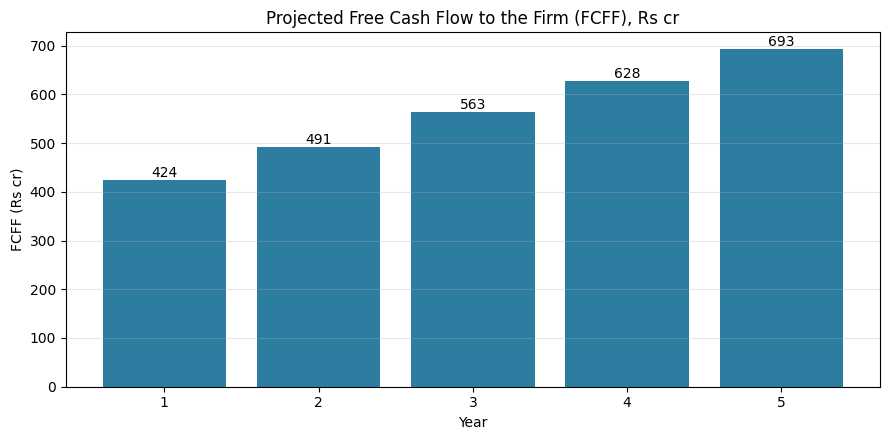

In [14]:
# Visualise FCFF in 5 years:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(proj["year"], proj["fcff"], color="#2C7DA0")
ax.set_title("Projected Free Cash Flow to the Firm (FCFF), Rs cr")
ax.set_xlabel("Year"); ax.set_ylabel("FCFF (Rs cr)"); ax.grid(alpha=0.3, axis="y")
for _, r in proj.iterrows():
    ax.annotate(f"{r['fcff']:.0f}", (r["year"], r["fcff"]), ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()


## Now, let us calculate the Terminal value

A company doesn't stop after 5 years. The **terminal value (TV)** captures all cash flows *beyond* the forecast, collapsed into one number at year 5. The standard **Gordon growth** formula assumes cash then grows forever at a modest rate `g`:

> **TV = FCFF in year 5 x (1 + g) / (WACC - g)**

Here `g` is the **terminal growth rate** — it must be small (no company outgrows the economy forever), so we use 5%.

In [15]:
g_term = assumptions["terminal_growth"]
fcff5 = proj["fcff"].iloc[-1]
tv = fcff5 * (1 + g_term) / (wacc - g_term)
print(f"FCFF year 5 = {fcff5:,.0f}")
print(f"Terminal growth g = {g_term:.0%}")
print(f"Terminal value at year 5 = {fcff5:,.0f} x (1+{g_term:.0%}) / ({wacc:.2%} - {g_term:.0%}) = {tv:,.0f} Rs cr")


FCFF year 5 = 693
Terminal growth g = 5%
Terminal value at year 5 = 693 x (1+5%) / (11.74% - 5%) = 10,793 Rs cr


---
## Now, we need to discount everything to today

Now bring every future rupee back to today's value by dividing by `(1 + WACC)` for each year it's away. Add up the discounted FCFFs and the discounted terminal value to get **Enterprise Value (EV)** — the value of the whole business. Then:

> **Equity value = Enterprise value - Net debt**, and **value per share = Equity value / shares**.

(*Why subtract net debt?* EV is what the whole business is worth to *all* investors; shareholders only get what's left after lenders are paid.)


In [16]:
proj["discount_factor"] = [(1 + wacc) ** -yr for yr in proj["year"]]
proj["pv_fcff"] = proj["fcff"] * proj["discount_factor"]

pv_fcff_total = proj["pv_fcff"].sum()
pv_tv = tv * (1 + wacc) ** -5

ev = pv_fcff_total + pv_tv
net_debt = fin.loc[fin["item"] == "Net debt", "FY25"].values[0]
shares = fin.loc[fin["item"] == "Shares outstanding (crore)", "FY25"].values[0]
equity_value = ev - net_debt
per_share = equity_value / shares

print(proj[["year", "fcff", "discount_factor", "pv_fcff"]].round(3).to_string(index=False))
print(f"\nPV of FCFF (years 1-5):  {pv_fcff_total:8,.0f} Rs cr")
print(f"PV of terminal value:    {pv_tv:8,.0f} Rs cr   <- {pv_tv/ev:.0%} of EV")
print(f"Enterprise value (EV):   {ev:8,.0f} Rs cr")
print(f"Less: net debt:          {net_debt:8,.0f} Rs cr")
print(f"Equity value:            {equity_value:8,.0f} Rs cr")
print(f"VALUE PER SHARE:         Rs {per_share:,.1f}  (on {shares:.0f} crore shares)")


 year    fcff  discount_factor  pv_fcff
    1 424.000            0.895  379.461
    2 491.288            0.801  393.494
    3 563.170            0.717  403.685
    4 627.521            0.642  402.562
    5 692.531            0.574  397.598

PV of FCFF (years 1-5):     1,977 Rs cr
PV of terminal value:       6,196 Rs cr   <- 76% of EV
Enterprise value (EV):      8,173 Rs cr
Less: net debt:             1,420 Rs cr
Equity value:               6,753 Rs cr
VALUE PER SHARE:         Rs 168.8  (on 40 crore shares)


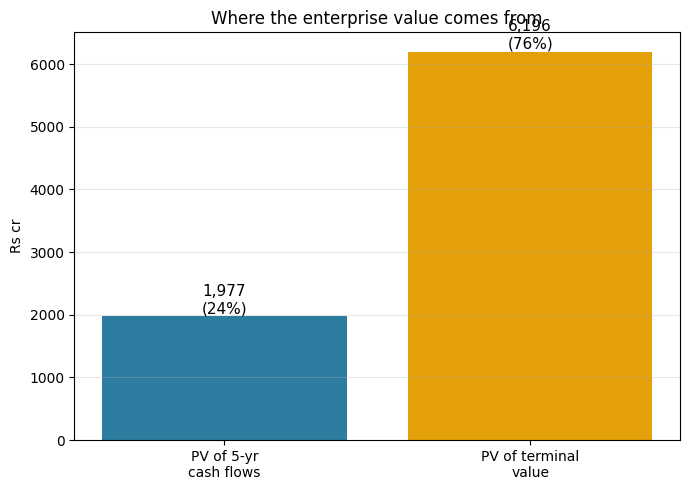

In [17]:
# Visualize Enterpise Value = PV of 5 year Future Cash flows projected + PV of Terminal Value
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["PV of 5-yr\ncash flows", "PV of terminal\nvalue"], [pv_fcff_total, pv_tv],
       color=["#2C7DA0", "#E3A008"])
ax.set_title("Where the enterprise value comes from")
ax.set_ylabel("Rs cr"); ax.grid(alpha=0.3, axis="y")
for i, v in enumerate([pv_fcff_total, pv_tv]):
    ax.annotate(f"{v:,.0f}\n({v/ev:.0%})", (i, v), ha="center", va="bottom", fontsize=11)
plt.tight_layout(); plt.show()


## confirm WACC − terminal_growth ≥ 1

In [19]:
diff_w = wacc - g_term
print("Difference of wacc - terminal growth rate (is greater than = 1):  ",diff_w)

Difference of wacc - terminal growth rate (greater than = 1):   0.067375


## Let us Produce a sensitivity table varying the discount rate and terminal growth rate by ±1 percentage point each (a 3×3 grid).

Thus you get varying wacc rates:
11.74% +1,
11.74%
11.74% -1

and varying terminal growth rate:
5%+1,
5%
5%-1

In [21]:
def dcf_per_share(wacc_v, g_v):
    tv_ = fcff5 * (1 + g_v) / (wacc_v - g_v)
    pv_f = sum(proj["fcff"].iloc[i] * (1 + wacc_v) ** -(i + 1) for i in range(5))
    pv_t = tv_ * (1 + wacc_v) ** -5
    return (pv_f + pv_t - net_debt) / shares

waccs = [0.1074, 0.1174, 0.1274]
grows = [0.04, 0.05, 0.06]
table = pd.DataFrame(
    {f"g={g:.0%}": [round(dcf_per_share(w, g), 0) for w in waccs] for g in grows},
    index=[f"WACC={w:.2%}" for w in waccs],
)
print("Value per share (Rs) under different WACC and terminal growth:")
print(table.to_string())


Value per share (Rs) under different WACC and terminal growth:
              g=4%   g=5%   g=6%
WACC=10.74%  176.0  205.0  248.0
WACC=11.74%  147.0  169.0  197.0
WACC=12.74%  126.0  142.0  162.0


The other method: multiples (comparables)

The multiples approach skips forecasting and compares ratios with similar companies worth, per rupee of EBITDA or profit?* Two common multiples:
- **EV/EBITDA** — enterprise value divided by EBITDA. Apply the peer median to our EBITDA → our EV.
- **P/E** — price (equity value) divided by earnings (PAT). Apply the peer median to our PAT → our equity value.

We use the **median** of peers (robust to one weird company).

In [24]:
peers = pd.read_csv("/peer_multiples.csv")
print(peers.to_string(index=False))

ev_ebitda_med = peers["ev_ebitda"].median()
pe_med = peers["pe_ratio"].median()
print(f"\nPeer median EV/EBITDA = {ev_ebitda_med:.1f}x")
print(f"Peer median P/E       = {pe_med:.1f}x")


 company  ev_ebitda  pe_ratio  revenue_growth_%  ebitda_margin_%
RazonPay       11.5      24.1               9.5             13.6
   Swipe       13.8      31.7              17.8             10.1
  Paypal        9.2      22.0               6.1              9.4

Peer median EV/EBITDA = 11.5x
Peer median P/E       = 24.1x


## Calculate the ratios:
- EV/EBITDA
- P/E
- EPS

In [25]:
ebitda_fy25 = fin.loc[fin["item"] == "EBITDA", "FY25"].values[0]
pat_fy25 = fin.loc[fin["item"] == "Profit after tax (PAT)", "FY25"].values[0]

# EV/EBITDA route
ev_mult = ev_ebitda_med * ebitda_fy25
ps_evebitda = (ev_mult - net_debt) / shares

# P/E route
equity_pe = pe_med * pat_fy25
ps_pe = equity_pe / shares

print(f"EV/EBITDA approach: {ev_ebitda_med:.1f}x x EBITDA {ebitda_fy25:,.0f} = EV {ev_mult:,.0f}")
print(f"   -> equity {ev_mult-net_debt:,.0f} -> per share Rs {ps_evebitda:,.0f}")
print(f"P/E approach:       {pe_med:.1f}x x PAT {pat_fy25:,.0f} = equity {equity_pe:,.0f}")
print(f"   -> per share Rs {ps_pe:,.0f}")


EV/EBITDA approach: 11.5x x EBITDA 1,113 = EV 12,800
   -> equity 11,380 -> per share Rs 284
P/E approach:       24.1x x PAT 612 = equity 14,749
   -> per share Rs 369


## Visualize all the estimates side by side:
- See the EPS using all different methods and assumptions

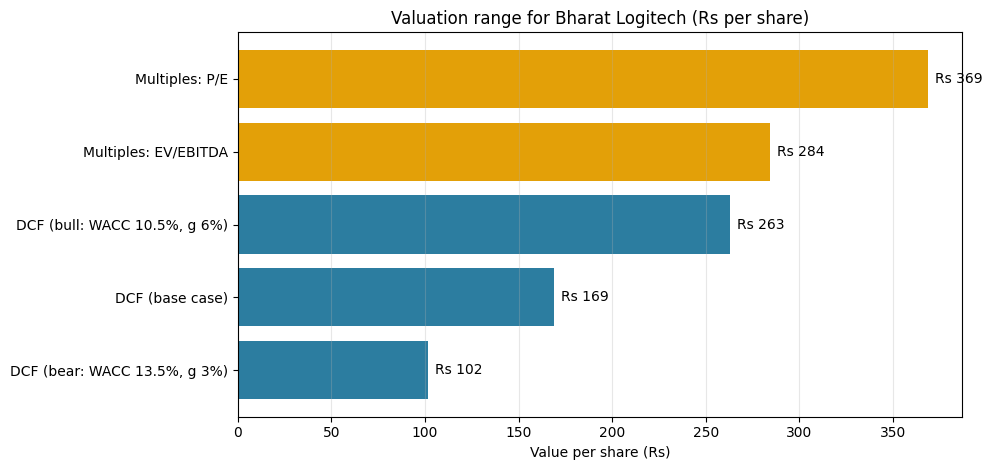

Range: Rs 102 to Rs 369 per share
DCF base case: Rs 169   |   Multiples midpoint: Rs 327


In [26]:
estimates = {
    "DCF (base case)": per_share,
    "DCF (bear: WACC 13.5%, g 3%)": dcf_per_share(0.135, 0.03),
    "DCF (bull: WACC 10.5%, g 6%)": dcf_per_share(0.105, 0.06),
    "Multiples: EV/EBITDA": ps_evebitda,
    "Multiples: P/E": ps_pe,
}
est = pd.Series(estimates).sort_values()

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ["#2C7DA0" if "DCF" in k else "#E3A008" for k in est.index]
ax.barh(est.index, est.values, color=colors)
for i, v in enumerate(est.values):
    ax.annotate(f"Rs {v:,.0f}", (v, i), xytext=(5, 0), textcoords="offset points", va="center", fontsize=10)
ax.set_title("Valuation range for Bharat Logitech (Rs per share)")
ax.set_xlabel("Value per share (Rs)"); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

print(f"Range: Rs {est.min():,.0f} to Rs {est.max():,.0f} per share")
print(f"DCF base case: Rs {per_share:,.0f}   |   Multiples midpoint: Rs {(ps_evebitda+ps_pe)/2:,.0f}")


## As you can see the Valuation ranges from EPS 102 to 369

Our assumptions make the valuation calcluation sensitive.
And the Multiples although are  quick to use and calcualte and market-grounded, but they inherit issues like the peers must be *genuinely* comparable and if the whole sector is over- or under-priced, your answer is to